# Aufgabe B3

In [1]:
import pandas as pd
import numpy as np
import regex as re
from collections import defaultdict as ddict
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as pl

#### a)

In [2]:
# Wörter des Body zählen nach Regex-Anweisung
def countWords(body: str,reg: str):
    result = []

    body = body.lower()
    body_words = re.split(reg, body)
    body_words_unique = list(set(body_words))

    for i in body_words_unique:
        result.append((i, body_words.count(i)))
    return result

In [3]:
# A-Priori-WK
def aPriori(x, y):
    return x/y

In [4]:
def bedingte_wahrscheinlichkeit(x,y,label):
    w_in_label = x[y==label].sum(axis=0)
    gesamt_woerter_in_label = sum(w_in_label)
    result = (w_in_label + 1) / (gesamt_woerter_in_label + len(w_in_label))
    return result

In [5]:
email_body = pd.DataFrame(pd.read_csv("./InputsB3/email_body.csv", keep_default_na=False))
email_headers = pd.DataFrame(pd.read_csv("./InputsB3/email_headers.csv"))

word_count_matrix = ddict(dict)
email_body["body"] = email_body["body"].astype('string')
email_id = 0

# filtern leerzeichen und andere Sonderzeichen heraus
for i in email_body["body"]:
    word_count_matrix["label"][email_id] = email_body.iloc[email_id]["label"]

    word_counts = countWords(i,r"\W+")
    for j in word_counts:
        word_count_matrix[j[0]][email_id] = j[1]

    email_id += 1

# Null-Werte = 0 setzen
word_count_matrix_df = pd.DataFrame(word_count_matrix).fillna(0)
word_count_matrix_df_dropped_labels = word_count_matrix_df.drop("label",axis=1,inplace=False)

In [6]:
random_state0 = 0

# Train-Test-Split
X_train,X_test,y_train,y_test = train_test_split(word_count_matrix_df_dropped_labels,email_body["label"],random_state=random_state0,test_size=0.2,stratify=email_body["label"])

    stratify bewirkt, dass die Verteilung des angegebenen Features beim Split gleich bleibt.

In [7]:
# a priori WKs für Auftreten von Spam / keinem Spam
# P(spam)
p_spam = aPriori(np.sum(y_train==1), len(y_train))
# P(no spam)
p_nospam = aPriori(np.sum(y_train==0), len(y_train))

print(f"P(Spam) = {p_spam}", f"   P(no Spam) = {p_nospam}")

P(Spam) = 0.16666666666666666    P(no Spam) = 0.8333333333333334


In [8]:
# Naive-Bayes-Klassifikator
class Bayesclassifier :
    p_spam: float
    p_nospam: float
    p_word_spam = ddict(dict)
    p_word_nospam = ddict(dict)
    x_train: any
    y_train: any
    def fit(self,x_train, y_train):
        self.x_train = x_train
        self.y_train = y_train
        self.p_spam = aPriori(np.sum(y_train==1), len(y_train))
        self.p_nospam = aPriori(np.sum(y_train==0), len(y_train))
        self.p_word_spam = bedingte_wahrscheinlichkeit(x_train,y_train,1)
        self.p_word_nospam = bedingte_wahrscheinlichkeit(x_train,y_train,0)
        return self
    def predict(self,word_count):
        if self.x_train is None:
            print("model not Trained no prediction possible")
            return "model not Trained no prediction possible"
        log_p_spam = np.log(p_spam)
        log_p_nospam = np.log(p_nospam)
    #∏P(word|Spam) * P(Spam) / ∏P(word|no Spam) * P(no Spam)
        for j in word_count.keys():
            if j in self.x_train.columns and word_count[j] != 0.0:
                log_p_spam = log_p_spam + np.log(self.p_word_spam[j])
                log_p_nospam = log_p_nospam + np.log(self.p_word_nospam[j])
    # P(Email) = P(Email|Spam) + P(Email|no Spam)
    # p_mail = log_p_mail_spam_with_p_spam + log_p_mail_nospam_with_p_nospam
    # wir verzichten auf die normierung, da zum reinen vergleich diese nicht notwendig ist
        if log_p_spam > log_p_nospam:
            return 1
        return 0

In [9]:
bayesclassifier = Bayesclassifier().fit(X_train,y_train)
test_mail_is_spam = bayesclassifier.predict(X_test.iloc[50])
print(test_mail_is_spam)

0


### b)

In [10]:
# merkmal 1: Anzahl Wörter mit mehr als 3 Sonderzeichen
index = 0
for i in email_body["body"]:
    email_headers.loc[index, "sonderzeichen_groesser_3"] = len(re.findall(r'\b\w*[\W_]{3,}\w*\b',i))
    index += 1

#merkmal 2: Anzahl der Wörter mit mehr als 4 Uppercase buchstaben
index = 0
for i in email_body["body"]:
    email_headers.loc[index, "uppercase_groesser_4"] = len(re.findall(r'\b(?=(?:\w*[A-Z]){4})\w+\b',i))
    index += 1
    
print(email_headers)

                                           From  \
0                Robert Elz <kre@munnari.OZ.AU>   
1     Steve Burt <Steve_Burt@cursor-system.com>   
2                   Tim Chapman <timc@2ubh.com>   
3              Monty Solomon <monty@roscom.com>   
4     Stewart Smith <Stewart.Smith@ee.ed.ac.uk>   
...                                         ...   
2995             Rob <yelanotyami912@bot.or.th>   
2996                       bolttish@hotmail.com   
2997     Mary's Store <removeme@marysstore.com>   
2998            eBayInternetMarketing@yahoo.com   
2999                             email@hkem.com   

                                           Content-Type  \
0                        text/plain; charset="us-ascii"   
1                        text/plain; charset="US-ASCII"   
2                        text/plain; charset="US-ASCII"   
3                        text/plain; charset="us-ascii"   
4                        text/plain; charset="US-ASCII"   
...                              

### c)

In [11]:
def get_features_from_pipeline(pipeline,transformer_name):
    transformer = pipeline.named_steps[transformer_name]
    return transformer.get_feature_names_out()

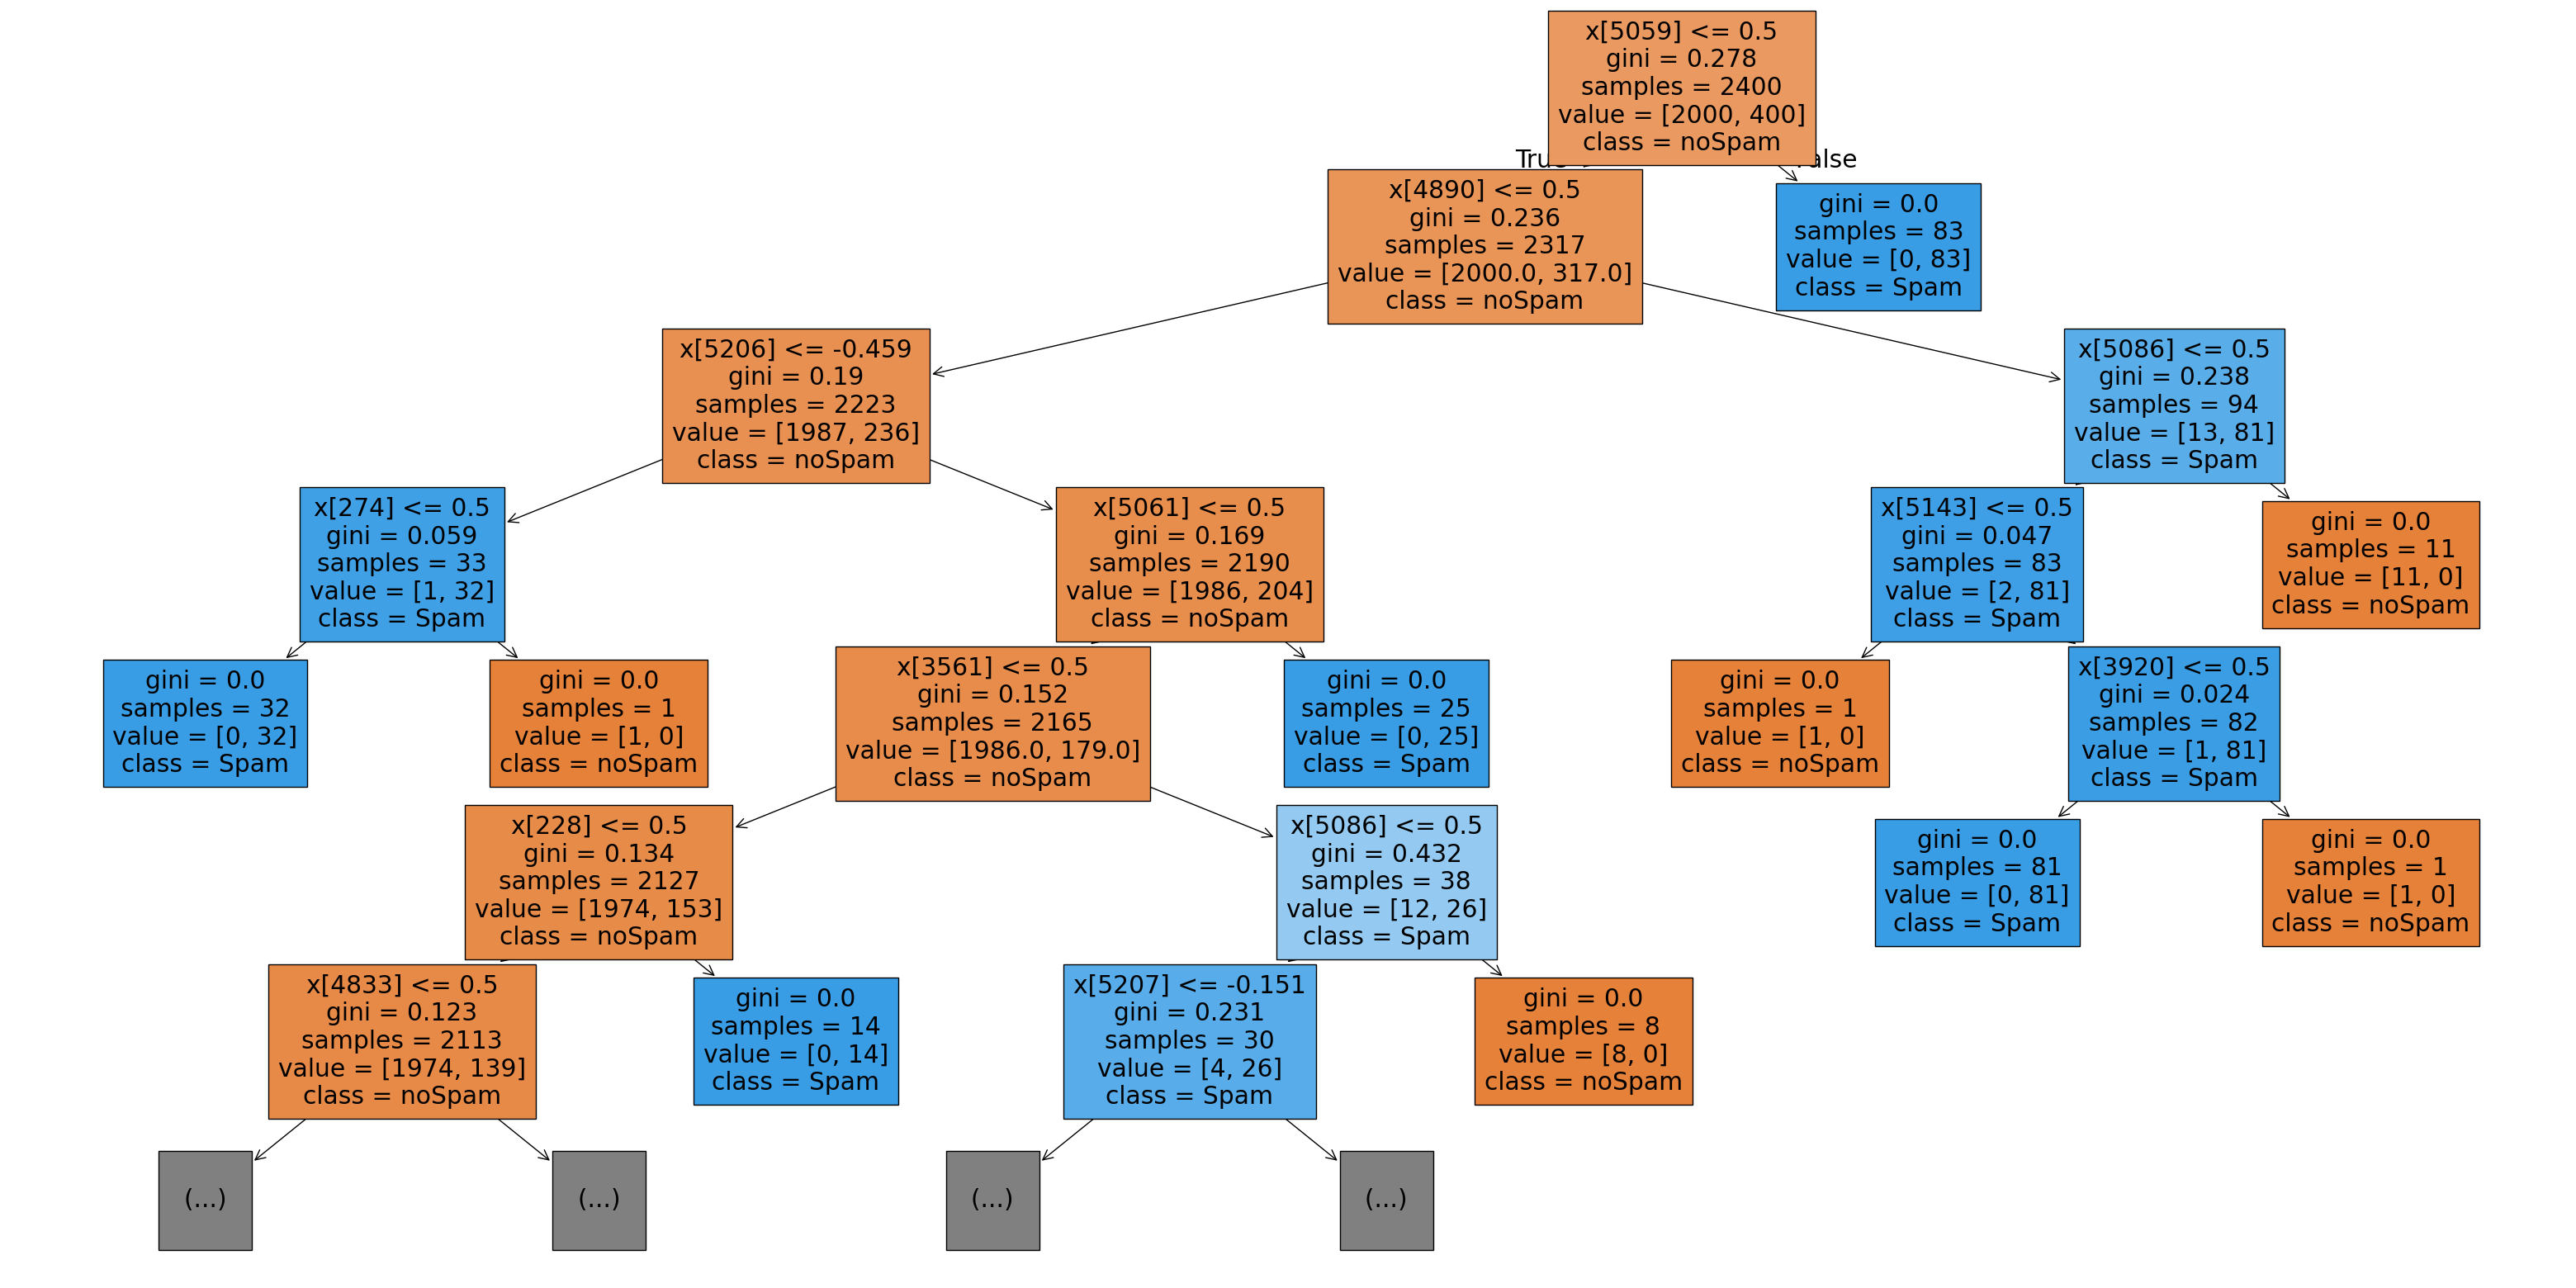

                                                feature  importance
5059  notSubjectandNotANumber__Content-Type_text/htm...    0.179111
4890  notSubjectandNotANumber__To_zzzz@spamassassin....    0.154446
5206               nummerical__sonderzeichen_groesser_3    0.094364
5061  notSubjectandNotANumber__Content-Type_text/htm...    0.062390
3561                                         text__your    0.041987
5086  notSubjectandNotANumber__Content-Type_text/pla...    0.041983
228                                           text__adv    0.036415
5207                   nummerical__uppercase_groesser_4    0.032640
2583                                           text__re    0.024314
4791         notSubjectandNotANumber__To_ler@lerctr.org    0.023869


In [12]:
from sklearn.tree import plot_tree

# Header-Daten Format anpassen
email_headers = email_headers.fillna("")
make_data_usable = ColumnTransformer(
    transformers=[
        ("text", CountVectorizer(),"Subject"),
        ("notSubjectandNotANumber",OneHotEncoder(handle_unknown='ignore'),["From","To","Content-Type","Organization","User-Agent"]),
        ("nummerical",StandardScaler(),["Attachement","sonderzeichen_groesser_3","uppercase_groesser_4"])
    ]
)

# Train-Test-Split
x_train_header,x_test_header,y_train_header,y_test_header = train_test_split(email_headers,email_body["label"],random_state=random_state0,test_size=0.2,stratify=email_body["label"])

# Entscheidungsbaum-Klassifikator
rft = Pipeline([
    ("make_data_usable",make_data_usable),
    ("classifier",DecisionTreeClassifier())
])
rft.fit(x_train_header,y_train_header)
decision_tree = rft.named_steps["classifier"]

# Entscheidungsbaum Plot
pl.figure(figsize=(40, 20))
plot_tree(decision_tree, filled=True,class_names=["noSpam","Spam"],max_depth=6)
# für feature names max_depth auf 2 ohne feature_names max_depth = 6 sonst einträge nicht lesbar    feature_names=get_features_from_pipeline(rft,"make_data_usable")
pl.show()
decision_tree_importance = decision_tree.feature_importances_
feature_names = get_features_from_pipeline(rft,"make_data_usable")
importance_df = pd.DataFrame({"feature":feature_names,"importance":decision_tree_importance})
print(importance_df.sort_values("importance",ascending=False).head(10))

## d)

In [13]:
predict_header = rft.predict(x_test_header)

predict_body = []
for i in range(len(X_test)):
    predict_body.append(bayesclassifier.predict(X_test.iloc[i]))
predict_body_arr = np.array(predict_body)

In [14]:
# wenn Ensemble pro Majority Voting ungleich, wird Spam klassifiziert
ensemble_predict  = []
for k in range(len(predict_body_arr)):
    if predict_body_arr[k] == predict_header[k]:
        ensemble_predict.append(predict_body_arr[k])
    else:
        ensemble_predict.append(1)


Beide Predictions werden hier verglichen: \
\
Klassifikator a -> Spam & Klassifikator b -> Spam => Spam \
Klassifikator a -> Spam & Klassifikator b -> kein Spam => Spam \
Klassifikator a -> kein Spam & Klassifikator b -> Spam => Spam \
Klassifikator a -> kein Spam & Klassifikator b -> kein Spam => kein Spam \
\
Im Grunde verodern wir hier einfach die Predictions.

## e)

In [15]:
from sklearn.metrics import classification_report

# Klassifikations-Reports
report_bayes_self = classification_report(y_true=y_test,y_pred=predict_body)
report_tree = classification_report(y_true=y_test_header,y_pred=predict_header)
report_ensemble = classification_report(y_true=y_test_header,y_pred=ensemble_predict)

print("Bayes self =\n",report_bayes_self)

print("Tree =\n",report_tree)

print("Ensemble =\n",report_ensemble)

Bayes self =
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       500
           1       0.95      0.95      0.95       100

    accuracy                           0.98       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.98      0.98      0.98       600

Tree =
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       500
           1       0.93      0.78      0.85       100

    accuracy                           0.95       600
   macro avg       0.94      0.88      0.91       600
weighted avg       0.95      0.95      0.95       600

Ensemble =
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       500
           1       0.92      0.99      0.95       100

    accuracy                           0.98       600
   macro avg       0.96      0.99      0.97       600
weighted avg       0.98      0.98      0

Wir würden anhand der Metriken uns für den Ensemble-Klassifikator entscheiden: Hier wurden zwar am meisten No-Spam-Mails als Spam klassifiziert, aber gleichzeitig wurden nahezu alle Spam-Mails erkannt. \
Wir sind der Ansicht lieber eine No-Spam-Mail fehlerhaft im Spam-Ordner als eine Spam-Mail fehlerhaft nicht im Spam-Ordner zu haben. \
Jedoch ist beim Ensemble-Klassifikator als Schwäche nicht zu vernachlässigen, dass mit 92% Precision der Spam Mails fast jede zehnten No-Spam-Mail im Spam-Ordner landet.